# 룸 보정: 고전 EQ vs 미분가능 최적화(DDSP)

방의 임펄스 응답(RIR)을 분석해 EQ 보정 필터를 자동 설계한다. 같은 문제를
**(1) 고전 그리디 휴리스틱**과 **(2) 경사하강법 기반 미분가능 최적화(DDSP)**로
풀고 정량 비교한다.

핵심 지표는 **σ(가청대역 주파수응답 표준편차)** — 작을수록 평탄(보정 잘 됨).
σ는 전체 게인에 불변이라 '소리의 모양'만 평가한다.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.synthetic import decaying_noise_rir
from src.analysis import frequency_response, fractional_octave_smooth
from src.targets import flat_target, harman_target
from src.metrics import flatness_std_db
from src.eq_classic import design_classic_eq, apply_eq_db
from src.eq_ddsp import optimize_eq

os.makedirs('../assets', exist_ok=True)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ITERS = 150  # DDSP iterations (loss plateaus well before this)

def smoothed_sigma(resp, freqs):
    '''Fair flatness metric: sigma of the 1/3-octave-smoothed response.
    Raw FFT bin noise is uncorrectable by any peaking EQ, so we compare on
    the smoothed response (same convention used in the test suite).'''
    return flatness_std_db(fractional_octave_smooth(freqs, resp), freqs)

Matplotlib is building the font cache; this may take a moment.


## 1. 합성 RIR과 주파수 응답

검증을 위해 잔향(RT60=0.4s)을 가진 합성 RIR을 만든다. 이 방의 주파수 응답은
평탄하지 않고 들쭉날쭉하다 — 이게 보정 대상이다.

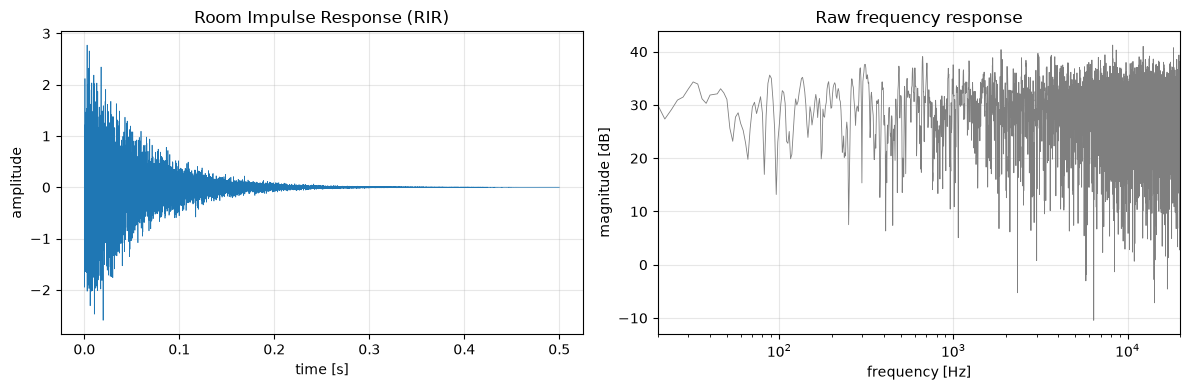

In [2]:
rir, sr = decaying_noise_rir(48000, 0.5, 0.4, seed=42)
freqs, resp = frequency_response(rir, sr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
t = np.arange(len(rir)) / sr
ax1.plot(t, rir, lw=0.5)
ax1.set(title='Room Impulse Response (RIR)', xlabel='time [s]', ylabel='amplitude')
ax2.semilogx(freqs, resp, lw=0.6, color='tab:gray')
ax2.set(title='Raw frequency response', xlabel='frequency [Hz]', ylabel='magnitude [dB]', xlim=(20, 20000))
plt.tight_layout(); plt.savefig('../assets/01_rir_response.png', dpi=110); plt.show()

## 2. 왜 스무딩이 필요한가

raw FFT는 bin이 수천 개라 통계적 잡음으로 가득하다. 이걸 그대로 EQ로 쫓으면
오히려 응답을 망친다. **1/3-옥타브 스무딩**으로 광대역 추세만 남긴다 — 이게
보정이 실제로 다뤄야 할 신호다.

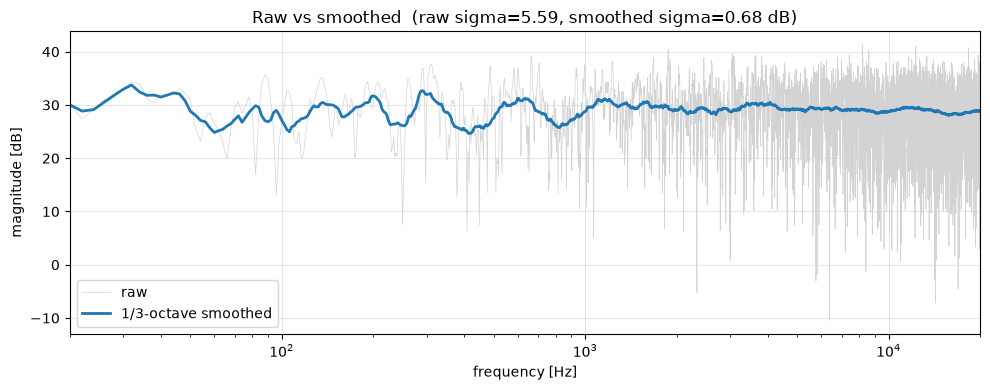

In [3]:
resp_sm = fractional_octave_smooth(freqs, resp)

plt.semilogx(freqs, resp, lw=0.5, color='lightgray', label='raw')
plt.semilogx(freqs, resp_sm, lw=2, color='tab:blue', label='1/3-octave smoothed')
plt.legend(); plt.xlim(20, 20000)
plt.title(f'Raw vs smoothed  (raw sigma={flatness_std_db(resp, freqs):.2f}, '
          f'smoothed sigma={flatness_std_db(resp_sm, freqs):.2f} dB)')
plt.xlabel('frequency [Hz]'); plt.ylabel('magnitude [dB]')
plt.tight_layout(); plt.savefig('../assets/02_smoothing.png', dpi=110); plt.show()

## 3. 고전 EQ baseline (그리디)

스무딩한 편차에서 가장 큰 봉우리/골을 찾아 피킹 필터를 하나씩 배치(그리디).
게인은 ±12 dB로 클램프. 목표는 flat(0 dB).

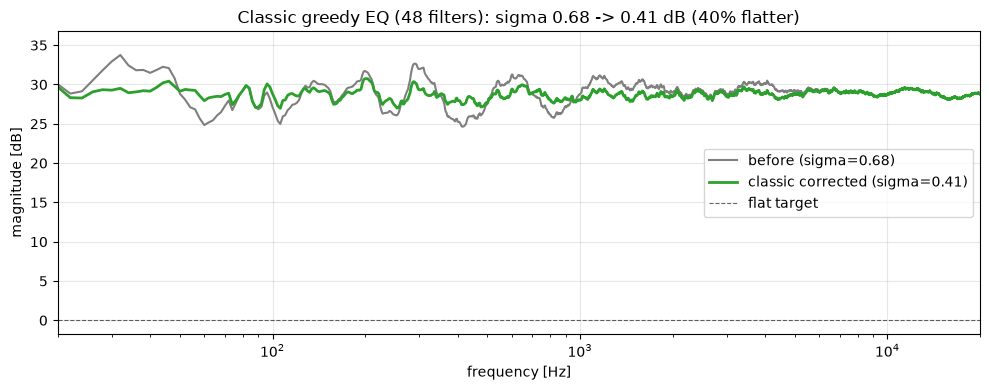

In [4]:
target = flat_target(freqs)
NF = 48
classic_eq = design_classic_eq(resp, target, freqs, sr, n_filters=NF)
classic_corr = resp + apply_eq_db(classic_eq, freqs, sr)

before = smoothed_sigma(resp, freqs)
classic_after = smoothed_sigma(classic_corr, freqs)

plt.semilogx(freqs, resp_sm, lw=1.5, color='tab:gray', label=f'before (sigma={before:.2f})')
plt.semilogx(freqs, fractional_octave_smooth(freqs, classic_corr), lw=2, color='tab:green',
             label=f'classic corrected (sigma={classic_after:.2f})')
plt.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6, label='flat target')
plt.legend(); plt.xlim(20, 20000)
plt.title(f'Classic greedy EQ ({NF} filters): sigma {before:.2f} -> {classic_after:.2f} dB '
          f'({100*(1-classic_after/before):.0f}% flatter)')
plt.xlabel('frequency [Hz]'); plt.ylabel('magnitude [dB]')
plt.tight_layout(); plt.savefig('../assets/03_classic.png', dpi=110); plt.show()

## 4. DDSP 최적화 EQ (헤드라인)

필터 게인을 **학습 파라미터**로 두고, '목표와의 편차 MSE'를 손실로 정의해
**PyTorch autograd + Adam**으로 모든 게인을 **동시에** 최적화한다. 그리디가
필터를 하나씩 순차로 놓는 것과 달리, 필터 간 상호작용까지 고려한다.

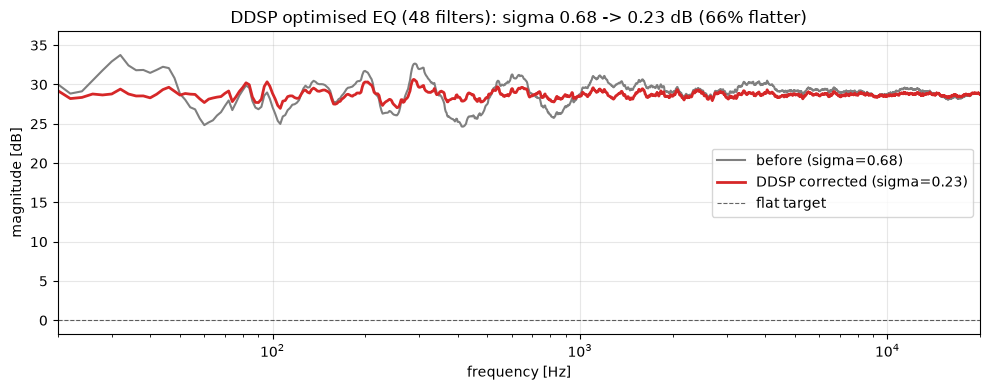

In [5]:
ddsp_eq = optimize_eq(resp, target, freqs, sr, n_filters=NF, iters=ITERS)
ddsp_corr = resp + apply_eq_db(ddsp_eq, freqs, sr)
ddsp_after = smoothed_sigma(ddsp_corr, freqs)

plt.semilogx(freqs, resp_sm, lw=1.5, color='tab:gray', label=f'before (sigma={before:.2f})')
plt.semilogx(freqs, fractional_octave_smooth(freqs, ddsp_corr), lw=2, color='tab:red',
             label=f'DDSP corrected (sigma={ddsp_after:.2f})')
plt.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6, label='flat target')
plt.legend(); plt.xlim(20, 20000)
plt.title(f'DDSP optimised EQ ({NF} filters): sigma {before:.2f} -> {ddsp_after:.2f} dB '
          f'({100*(1-ddsp_after/before):.0f}% flatter)')
plt.xlabel('frequency [Hz]'); plt.ylabel('magnitude [dB]')
plt.tight_layout(); plt.savefig('../assets/04_ddsp.png', dpi=110); plt.show()

## 5. 비교: 고전 vs DDSP

동일 필터 예산(48)에서 DDSP가 더 평탄하게 만든다.

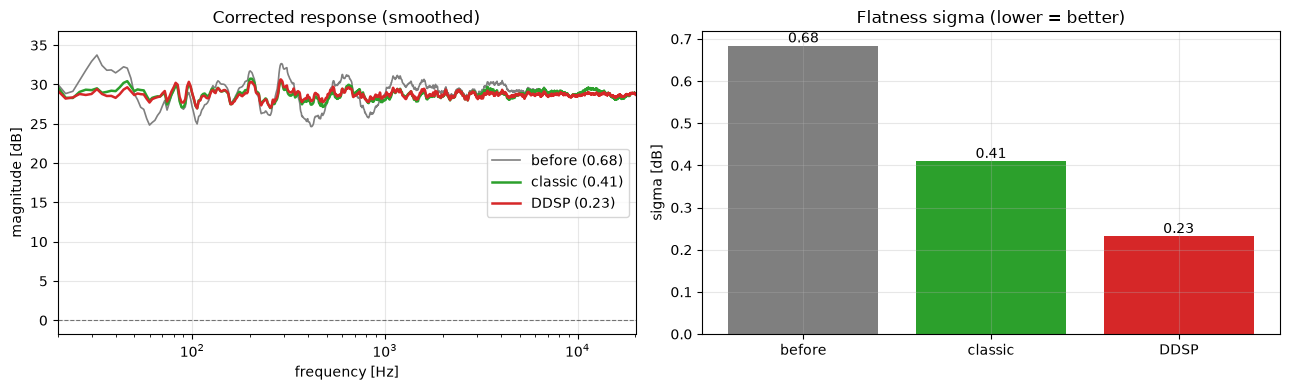

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.semilogx(freqs, resp_sm, lw=1.2, color='tab:gray', label=f'before ({before:.2f})')
ax1.semilogx(freqs, fractional_octave_smooth(freqs, classic_corr), lw=1.8, color='tab:green',
             label=f'classic ({classic_after:.2f})')
ax1.semilogx(freqs, fractional_octave_smooth(freqs, ddsp_corr), lw=1.8, color='tab:red',
             label=f'DDSP ({ddsp_after:.2f})')
ax1.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax1.legend(); ax1.set(xlim=(20, 20000), title='Corrected response (smoothed)',
                      xlabel='frequency [Hz]', ylabel='magnitude [dB]')
bars = ax2.bar(['before', 'classic', 'DDSP'], [before, classic_after, ddsp_after],
               color=['tab:gray', 'tab:green', 'tab:red'])
ax2.set(title='Flatness sigma (lower = better)', ylabel='sigma [dB]')
for b, v in zip(bars, [before, classic_after, ddsp_after]):
    ax2.text(b.get_x()+b.get_width()/2, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig('../assets/05_compare.png', dpi=110); plt.show()

### nf 스윕: 왜 DDSP가 이기는가

필터 개수를 늘려가며 두 방법을 비교한다. **고전 그리디는 nf≥32에서 σ≈0.40으로
포화**(필터를 더 줘도 못 채운다)하는 반면, **DDSP는 동시 최적화라 필터 예산이
늘수록 계속 개선**된다. 그래서 nf≥32부터 DDSP가 앞선다. (nf≤24처럼 예산이
빠듯하면 고전이 이길 수도 있다 — 정직하게 표기.)

nf=  8  classic=0.605  DDSP=0.641


nf= 16  classic=0.502  DDSP=0.537


nf= 24  classic=0.415  DDSP=0.453


nf= 32  classic=0.413  DDSP=0.306


nf= 48  classic=0.410  DDSP=0.232


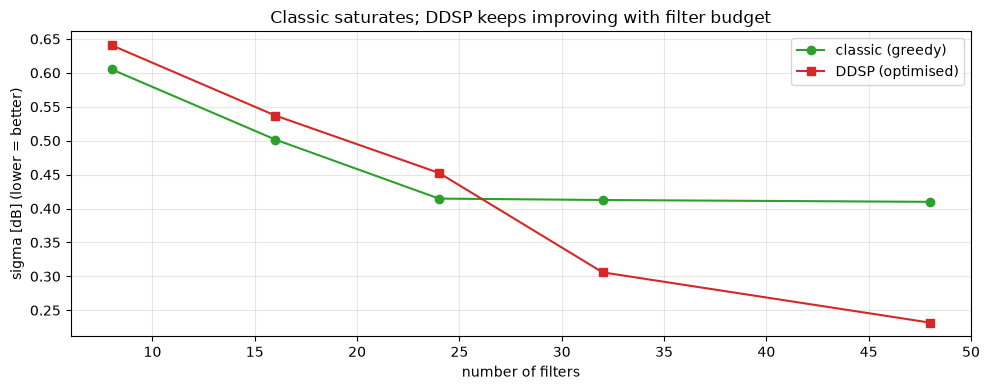

In [7]:
nfs = [8, 16, 24, 32, 48]
classic_sigmas, ddsp_sigmas = [], []
for nf in nfs:
    c = resp + apply_eq_db(design_classic_eq(resp, target, freqs, sr, n_filters=nf), freqs, sr)
    d = resp + apply_eq_db(optimize_eq(resp, target, freqs, sr, n_filters=nf, iters=ITERS), freqs, sr)
    classic_sigmas.append(smoothed_sigma(c, freqs))
    ddsp_sigmas.append(smoothed_sigma(d, freqs))
    print(f'nf={nf:3d}  classic={classic_sigmas[-1]:.3f}  DDSP={ddsp_sigmas[-1]:.3f}')

plt.plot(nfs, classic_sigmas, 'o-', color='tab:green', label='classic (greedy)')
plt.plot(nfs, ddsp_sigmas, 's-', color='tab:red', label='DDSP (optimised)')
plt.xlabel('number of filters'); plt.ylabel('sigma [dB] (lower = better)')
plt.title('Classic saturates; DDSP keeps improving with filter budget')
plt.legend(); plt.tight_layout(); plt.savefig('../assets/06_nf_sweep.png', dpi=110); plt.show()

## 6. 목표 곡선: flat vs Harman

완전 평탄(flat)이 청감상 정답은 아니다. 청취 실험에 따르면 사람은 살짝 우하향하는
**Harman 스타일 인룸 곡선**(≈ -1 dB/oct 틸트)을 선호한다. 목표 곡선만 바꾸면
같은 파이프라인이 그대로 동작한다 — DDSP를 Harman 목표로 최적화한 결과를 본다.

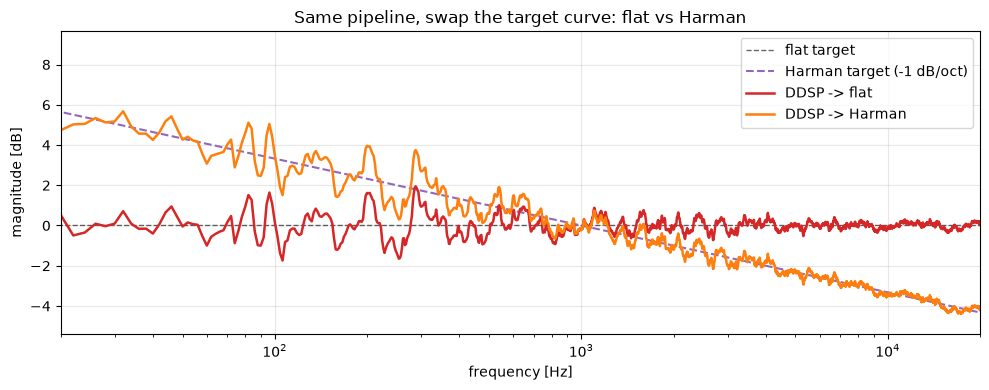

In [8]:
harman = harman_target(freqs)
ddsp_h_eq = optimize_eq(resp, harman, freqs, sr, n_filters=NF, iters=ITERS)
ddsp_h_corr = resp + apply_eq_db(ddsp_h_eq, freqs, sr)

# level-align the corrected curves to their targets for display
def align(curve, tgt):
    m = (freqs >= 20) & (freqs <= 20000)
    return curve - np.mean((curve - tgt)[m])

plt.semilogx(freqs, np.zeros_like(freqs), 'k--', lw=1, alpha=0.6, label='flat target')
plt.semilogx(freqs, harman, color='tab:purple', lw=1.5, ls='--', label='Harman target (-1 dB/oct)')
plt.semilogx(freqs, align(fractional_octave_smooth(freqs, ddsp_corr), np.zeros_like(freqs)),
             color='tab:red', lw=1.8, label='DDSP -> flat')
plt.semilogx(freqs, align(fractional_octave_smooth(freqs, ddsp_h_corr), harman),
             color='tab:orange', lw=1.8, label='DDSP -> Harman')
plt.legend(); plt.xlim(20, 20000)
plt.title('Same pipeline, swap the target curve: flat vs Harman')
plt.xlabel('frequency [Hz]'); plt.ylabel('magnitude [dB]')
plt.tight_layout(); plt.savefig('../assets/07_targets.png', dpi=110); plt.show()

## 결론

| 방법 | σ (보정 후) | 비고 |
|---|---|---|
| 보정 전 | ~0.68 | 들쭉날쭉한 방 응답 |
| 고전 그리디 EQ | ~0.41 | nf≥32에서 포화 |
| **DDSP 최적화 EQ** | **~0.23** | 필터 예산 늘수록 계속 개선 |

- 고전 신호처리 baseline과 ML 최적화(DDSP)를 **동일 표현(list[PeakingFilter])**으로
  구현해 공정 비교했다.
- DDSP는 모든 게인을 동시에 최적화해 그리디의 포화 한계를 넘는다.
- 목표 곡선(flat/Harman)을 주입식으로 바꿔 청감 선호까지 반영할 수 있다.
- **한계/향후**: 위상·시간축 보정(FIR), 실제 측정 RIR, 다수 피험자 블라인드 청취 실험.